**Introduzione alle librerie python per il ML**
Numpy permette di utilizzare delle strutture dati efficienti:
- gestisce array multidimensionali
- esegue operazioni matematiche veloci
- lavora con algebra lineare, statistiche e trasformazioni
In particolare, nel ML viene utilizzato per rappresentare dataset ed eseguire calcoli vettoriali efficienti.

Matplotlib è una libreria grafica che permette di creare: 
- grafici 2D
- grafici scientifici
- visualizzazioni dei dati
In particolare, nel ML viene utilizzato per esplorare i dati, visualizzare distribuzioni, vedere l'andamento dell'allenamento e confrontare i modelli.

Pandas è una libreria usata per manipolare, analizzare e pulire dati strutturati. Nel ML è uno degli strumenti più importanti perché permette di caricare e preparare i dataset prima di addestrare i modelli.
- legge dataset
- pulisce i dati
- filtra i dati
- gestisce valori mancanti
- analisi statisithce

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import os
import pandas as pd

In [2]:
center = np.array([0, 0]) # un array di due elementi
points = np.array([[0.5, 0.5, 1], [0.6, 1.16, 1], [1.14, 0.8, 1], [-1.1, -1.0, 1], [1.01, -0.9, 1],
                   [0.3, 0.5, 0], [-0.6, 0.6, 0], [0.2, -0.7, 0], [-0.8, -0.2, 0], [1.0, -0.5, 0], [-1.5, 0.1, 0]]) #matrice dei punti

In [3]:
print(points)
print(points[2, 1])
print(points[3:6, 1]) #slicing
print(points[:, 1]) #slicing

[[ 0.5   0.5   1.  ]
 [ 0.6   1.16  1.  ]
 [ 1.14  0.8   1.  ]
 [-1.1  -1.    1.  ]
 [ 1.01 -0.9   1.  ]
 [ 0.3   0.5   0.  ]
 [-0.6   0.6   0.  ]
 [ 0.2  -0.7   0.  ]
 [-0.8  -0.2   0.  ]
 [ 1.   -0.5   0.  ]
 [-1.5   0.1   0.  ]]
0.8
[-1.  -0.9  0.5]
[ 0.5   1.16  0.8  -1.   -0.9   0.5   0.6  -0.7  -0.2  -0.5   0.1 ]


In [4]:
a = np.arange(3, 11) 
print(a)
print(a[[1,6,4]]) # operazione di filtro

[ 3  4  5  6  7  8  9 10]
[4 9 7]


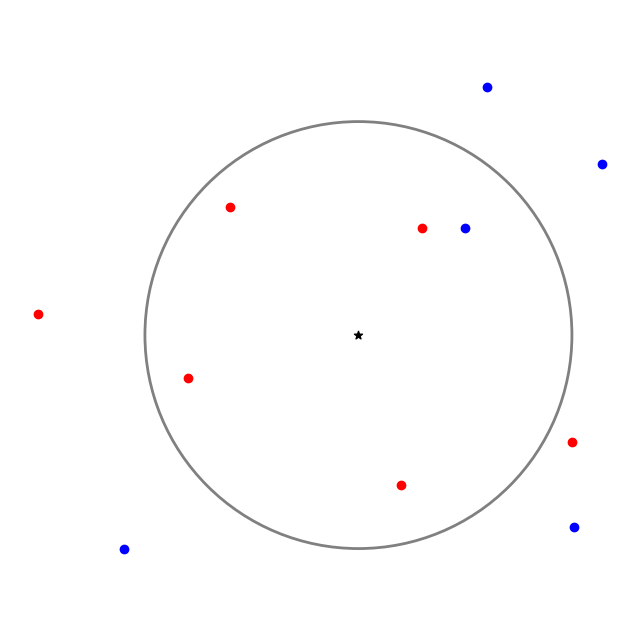

In [5]:
# ridefiniamo center e points solo per rendere questa cella indipendente dalla precedente
center = np.array([0,0])
points = np.array([[0.5, 0.5, 1], [0.6, 1.16, 1], [1.14, 0.8, 1], [-1.1, -1.0, 1],
                   [1.01, -0.9, 1], [0.3, 0.5, 0], [-0.6, 0.6, 0], [0.2, -0.7, 0],
                   [-0.8, -0.2, 0], [1.0, -0.5, 0], [-1.5, 0.1, 0]])
fig, ax = plt.subplots(figsize=(8, 8))  # nuova figura di dimensione 8x8
ax.scatter(center[0], center[1], color = 'black', marker = '*')  # disegno del punto al centro come una stella
circle = patches.Circle(center, 1, edgecolor = 'gray', facecolor = None, alpha = 1, linewidth = 2, fill = False)  # definisce cerchio centrato 
# disegna i punti con etichetta 1 definendo la lista delle coordinate x e y usando
# list comprehension (vedere)
ax.scatter([x for x,y,t in points if t == 1], [y for x,y,t in points if t == 1], color = 'blue', marker = 'o')
# stessa cosa con etichetta 0
ax.scatter([x for x,y,t in points if t == 0], [y for x,y,t in points if t == 0], color = 'red', marker = 'o')
# aggiunge cerchio al disegno
ax.add_patch(circle)
ax.axis('equal')
ax.axis('off')
# salve disegno
plt.savefig('fig-l2-01-knn.png', dpi = 120, bbox_inches='tight')
# mostra disegno
plt.show()

**Definizione della classe per il problema KNN**
Il problema del k-NN è un problema di classificazione basato sulla somiglianza: dato un oggetto ignoto, deve scegliere a quale categoria appartiene basandosi su chi gli sta più vicino.
Prendiamo ad esempio il dataset iris, le features che il problema considera sono:


**Le funzioni**
Le funzioni da definire sono:
- euclidean_dist: La lunghezza del vettore a0 - a1.

In [6]:
def euclidean_dist(a0, a1):
    return np.linalg.norm(a0 - a1)

- selection_sort: Trova i primi k elementi in ordine di grandezza dell'array a. La funzione da minimizzare è key, funzione di a e x (p.e. la distanza da x agli elementi di a)

In [7]:
def selection_sort(a, x, k = None, key = None):
    '''
    input: a, una sequenza; x un oggetto, k un intero; key una funzione dei valori di a e x
    
    restituisce un array con i primi k elementi di a in ordine di grandezza rispetto
    alla funzione key

    se k non indicato, viene usata per k la dimensione dell'array

    se key non indicato, viene usata la funzione identità 
    '''
    if k == None or k > len(a) or k < 0:
        k = len(a)
    if key == None:
        key = lambda y, _: y
    idxs = [] # idxs[:i] le posizioni dei primi i elementi di a in ordine di grandezza 
        
    for i in range(k):  # eseguito k volte
        # cerchiamo idxs[k]
        m = None # il valore del candidato
        for j, v in enumerate(a): # eseguito n volte (dove n = len(a)) 
            if m == None or key(v, x) < key(a[m], x):  # tempo costante O(1)
                if j not in idxs:  # O(k) può diventare  costante O(1) se si usa un set
                    m = j

        # costo del for interno O(kn)
        idxs.append(m)  # O(1)

    # costo totale è O(nk) (con set) se k piccolo il tempo è lineare
            
    return idxs

Assumiamo che len(a) sia n. Se k è piccolo, l'algoritmo è efficiente, richiede \Theta(kn) operazioni. Le operazioni potrebbero scendere \Theta(klogn) se impieghiamo la struttura dati k-d tree. Il numero di operazioni per costruire l'albero è \Theta(nlog^2n).
- model: calcola la moda di un array-like, ovvero l'elemento più frequente, ritornando l'elemento ed il numero di volte in cui compare.

In [8]:
def model (a):
    '''
    parametro: a, un array-like

    return: l'elemento più frequente ed il numero di occorrenze
    '''
    # lista di elementi senza ripetizioni, numero di occorrenze
    items, cnts = np.unique(np.array(a), return_counts=True ) 
    return items[np.argmax(cnts)], max(cnts)    

**La classe KNN**

In [9]:
class KNN(object):
    def __init__(self, k = 5, distance = None):
        self.k = k
        if distance == None:
            self._dist = euclidean_dist
        else:
            self._dist = distance
    
    def fit(self, X, y):
        self.X = X
        self.y = y
    
    def predict(self, x):
        k_indices = selection_sort(self.X, x, k = 5, key = self._dist)
        return model(self.y[k_indices])

**IRIS**

In [13]:
s = os.path.join('materiale_2026/dataset', '01-02-iris.csv')
df = pd.read_csv(s, header=None, encoding='utf-8')
X = df.iloc[:, [0,1]].values
y = df.iloc[:, 4].values
df

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


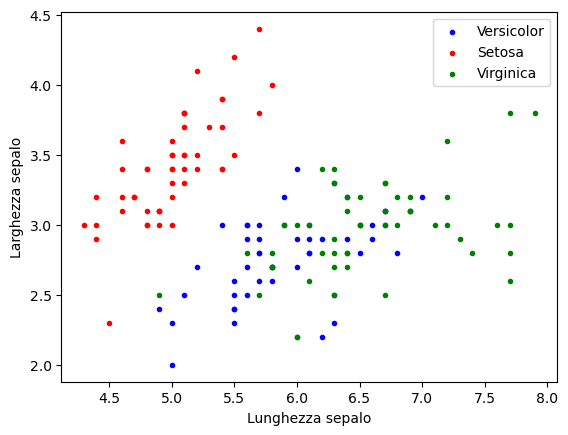

In [14]:
versicolor = X[np.where(y == 'Iris-versicolor')]
setosa = X[np.where(y == 'Iris-setosa')]
virginica = X[np.where(y == 'Iris-virginica')]
plt.scatter(versicolor[:,0], versicolor[:,1], color='blue', marker='.', label='Versicolor')
plt.scatter(setosa[:,0], setosa[:,1], color='red', marker='.', label='Setosa')
plt.scatter(virginica[:,0], virginica[:,1], color='green', marker='.', label='Virginica')
plt.xlabel('Lunghezza sepalo')
plt.ylabel('Larghezza sepalo')
plt.legend()
plt.savefig('fig-l2-02-iris_01.png', dpi=120, bbox_inches='tight')

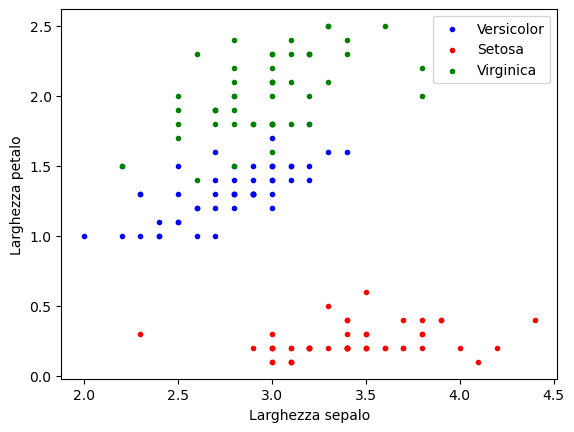

In [15]:
X = df.iloc[:, [1,3]].values
y = df.iloc[:, 4].values

versicolor = X[np.where(y == 'Iris-versicolor')]
setosa = X[np.where(y == 'Iris-setosa')]
virginica = X[np.where(y == 'Iris-virginica')]

plt.scatter(versicolor[:,0], versicolor[:,1], color='blue', marker='.', label='Versicolor')
plt.scatter(setosa[:,0], setosa[:,1], color='red', marker='.', label='Setosa')
plt.scatter(virginica[:,0], virginica[:,1], color='green', marker='.', label='Virginica')
plt.xlabel('Larghezza sepalo')
plt.ylabel('Larghezza petalo')

plt.legend()

plt.savefig('fig-l2-03-iris_13.png', dpi=120, bbox_inches='tight')

**Classificazione e testing di KNN**
Il dataset viene diviso in due parti, il training set e il test set. Il primo viene utilizzato per addestrare il classificatore (nel caso di KNN, solo memorizzazione dati). Il secondo viene utilizzato per verificare il modello, si classificano i dati usando l'algoritmo e si confrontano i risultati con le etichette reali.
**Funzione di split**

In [16]:
def train_test_split(X, y, train_size = 0.7):
    n = X.shape[0]
    train_idxs = np.random.choice(n, size = int(n*train_size), replace=False)
    test_idxs =  np.setdiff1d(np.arange(n), train_idxs)
    return X[train_idxs], y[train_idxs], X[test_idxs], y[test_idxs]

In [17]:
def train_test_split_esercizio_1(X, y, train_size = 0.7):
    etichette = np.unique(y)
    n = X.shape[0]
    train_idxs = []
    for lab in etichette:
        n0 = np.where(y==lab)[0].shape[0] #numero di campioni con etichetta lab
        train_idxs.append(np.random.choice(np.where(y==lab)[0], size = int(n0*train_size), replace = False))
    train_idxs = np.concatenate(train_idxs)
    test_idxs = np.setdiff1d(np.arange(n), train_idxs)
    return X[train_idxs], y[train_idxs], X[test_idxs], y[test_idxs]

In [18]:
X = df.iloc[:, :-1].values  # i valori in tutte le righe e tutte le colonne tranne l'ultima
y = df.iloc[:, 4].values # i valori nell'ultima colonna
#y = df.iloc[:, -1].values # alteternativa alla precedente
#X_train, y_train, X_test, y_test = train_test_split(X, y)
X_train, y_train, X_test, y_test = train_test_split_esercizio_1(X, y)

Verifico la distribuzione delle etichette:

In [19]:
np.unique(y_train, return_counts=True)


(array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object),
 array([35, 35, 35]))

Definiamo una nuova istanza del modello KNN

In [20]:
knn = KNN()
knn.fit(X_train, y_train)

In [21]:
x, t = X_test[0], y_test[0]
print(knn.predict(x), t)

('Iris-setosa', np.int64(5)) Iris-setosa


In [22]:
for x, t in zip(X_test[:10], y_test[:10]):
    print(x,t, knn.predict(x))

[4.6 3.1 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.4 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.4 3.7 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.8 3.4 1.6 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[4.3 3.  1.1 0.1] Iris-setosa ('Iris-setosa', np.int64(5))
[5.8 4.  1.2 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.4 3.9 1.3 0.4] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.  1.6 0.2] Iris-setosa ('Iris-setosa', np.int64(5))
[5.  3.4 1.6 0.4] Iris-setosa ('Iris-setosa', np.int64(5))
[5.2 3.5 1.5 0.2] Iris-setosa ('Iris-setosa', np.int64(5))


**Valutazione**

In [23]:
[knn.predict(x)[0] for x in X_test]

['Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-setosa',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-virginica',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-versicolor',
 'Iris-virginica',
 'Iris-versicolor',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica',
 'Iris-virginica']

In [24]:
# Booleano contenente l'esito dei confronti tra etichette reali e predette
preds = np.array([knn.predict(x)[0] for x in X_test]) == y_test
print(preds)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True False
  True  True  True  True  True  True  True False  True  True  True  True
  True  True  True  True  True  True  True  True  True]


**Accuratezza**

In [25]:
accuracy=np.sum(preds)/preds.shape[0]
print('Accuratezza: ',  accuracy)   # oppure np.sum(preds)/len(preds) 

Accuratezza:  0.9555555555555556


**Esercizi per il fine settimana**
1. Modificare la funzione train_test_split in modo da garantire che i dataset in output abbiano la stessa distribuzione delle etichette del dataset in input.
Soluzione: è stato implementata la funzione train_test_split_esercizio_1 dove, nell'array finale vengono suddivise in modo equo tutte le etichette presenti nel dataset



2. Nell'esempio della classificazione degli iris, studiare l'importanza delle quattro feature cercando di individuare, se possibile, quella meno utile.

In [26]:
for i in range(4):
    X_train_ridotto = np.delete(X_train, i, axis=1)
    X_test_ridotto = np.delete(X_test, i, axis=1)
    knn_ridotto = KNN()
    knn_ridotto.fit(X_train_ridotto, y_train)
    preds_ridotte = np.array([knn_ridotto.predict(x)[0] for x in X_test_ridotto]) == y_test
    acc_ridotta = np.sum(preds_ridotte) / len(preds_ridotte)
    diff = accuracy - acc_ridotta
    print(f"Escludendo '{i}': Accuratezza = {acc_ridotta:.4f} (Variazione: {diff:+.4f})")

Escludendo '0': Accuratezza = 0.9556 (Variazione: +0.0000)
Escludendo '1': Accuratezza = 0.9778 (Variazione: -0.0222)
Escludendo '2': Accuratezza = 0.9333 (Variazione: +0.0222)
Escludendo '3': Accuratezza = 0.9556 (Variazione: +0.0000)


Ne segue che la features 4 (o 3-zo elemento dell'array) è meno significativa